In [173]:
#!pip install scikit-learn

In [174]:
import pandas as pd
import datetime as dt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

In [220]:
#Import the forecast results data
df_results = pd.read_csv(r'D:\Modelling\demandcast\demandcast\ml_models\results\forecasts\with_xgboost_model_20260513_135637\using_assembled_data_for_forecasting_20260513_135700\all_20260513_135706.csv')

In [221]:
df_train = pd.read_csv(r'D:\Modelling\demandcast\demandcast\data\assembled\assembled_data_for_training_20260513_134256_actual.csv')
df_train = df_train[['Time (UTC)','Entity code','Load (MW)']]

In [222]:
df_results = df_results[['Time (UTC)','Entity code','Forecast load (MW)']]

In [223]:
df_results['Time (UTC)'] = pd.to_datetime(df_results['Time (UTC)'])
df_train['Time (UTC)'] = pd.to_datetime(df_train['Time (UTC)'])

In [224]:
df_results

,Time (UTC),Entity code,Forecast load (MW)
0,2022-12-31 16:00:00,SGP,5596.456621
1,2022-12-31 17:00:00,SGP,5627.908454
2,2022-12-31 18:00:00,SGP,5486.990559
3,2022-12-31 19:00:00,SGP,5391.100853
4,2022-12-31 20:00:00,SGP,5360.630780
...,...,...,...
26299,2025-12-31 11:00:00,SGP,7615.733285
26300,2025-12-31 12:00:00,SGP,7546.140309
26301,2025-12-31 13:00:00,SGP,7378.807259
26302,2025-12-31 14:00:00,SGP,7123.005962


In [225]:
df = pd.merge(df_train, df_results, on = ['Time (UTC)','Entity code'],how = 'left')

In [226]:
df['Load (MW)']=pd.to_numeric(df['Load (MW)'])

In [227]:
df['Forecast load (MW)']=pd.to_numeric(df['Forecast load (MW)'])

In [228]:
df['Time (LOCAL)'] = df['Time (UTC)'].dt.tz_localize('UTC').dt.tz_convert('Asia/Singapore')

In [219]:
df

,Time (UTC),Entity code,Load (MW),Forecast load (MW),Time (LOCAL)
0,2022-12-31 16:00:00,SGP,5794.237222,5596.456621,2023-01-01 00:00:00+08:00
1,2022-12-31 17:00:00,SGP,5715.322086,5627.908454,2023-01-01 01:00:00+08:00
2,2022-12-31 18:00:00,SGP,5600.664392,5486.990559,2023-01-01 02:00:00+08:00
3,2022-12-31 19:00:00,SGP,5432.126001,5391.100853,2023-01-01 03:00:00+08:00
4,2022-12-31 20:00:00,SGP,5320.085898,5360.630780,2023-01-01 04:00:00+08:00
...,...,...,...,...,...
26299,2025-12-31 11:00:00,SGP,7189.638850,7615.733285,2025-12-31 19:00:00+08:00
26300,2025-12-31 12:00:00,SGP,7101.195500,7546.140309,2025-12-31 20:00:00+08:00
26301,2025-12-31 13:00:00,SGP,6990.700450,7378.807259,2025-12-31 21:00:00+08:00
26302,2025-12-31 14:00:00,SGP,6784.926950,7123.005962,2025-12-31 22:00:00+08:00


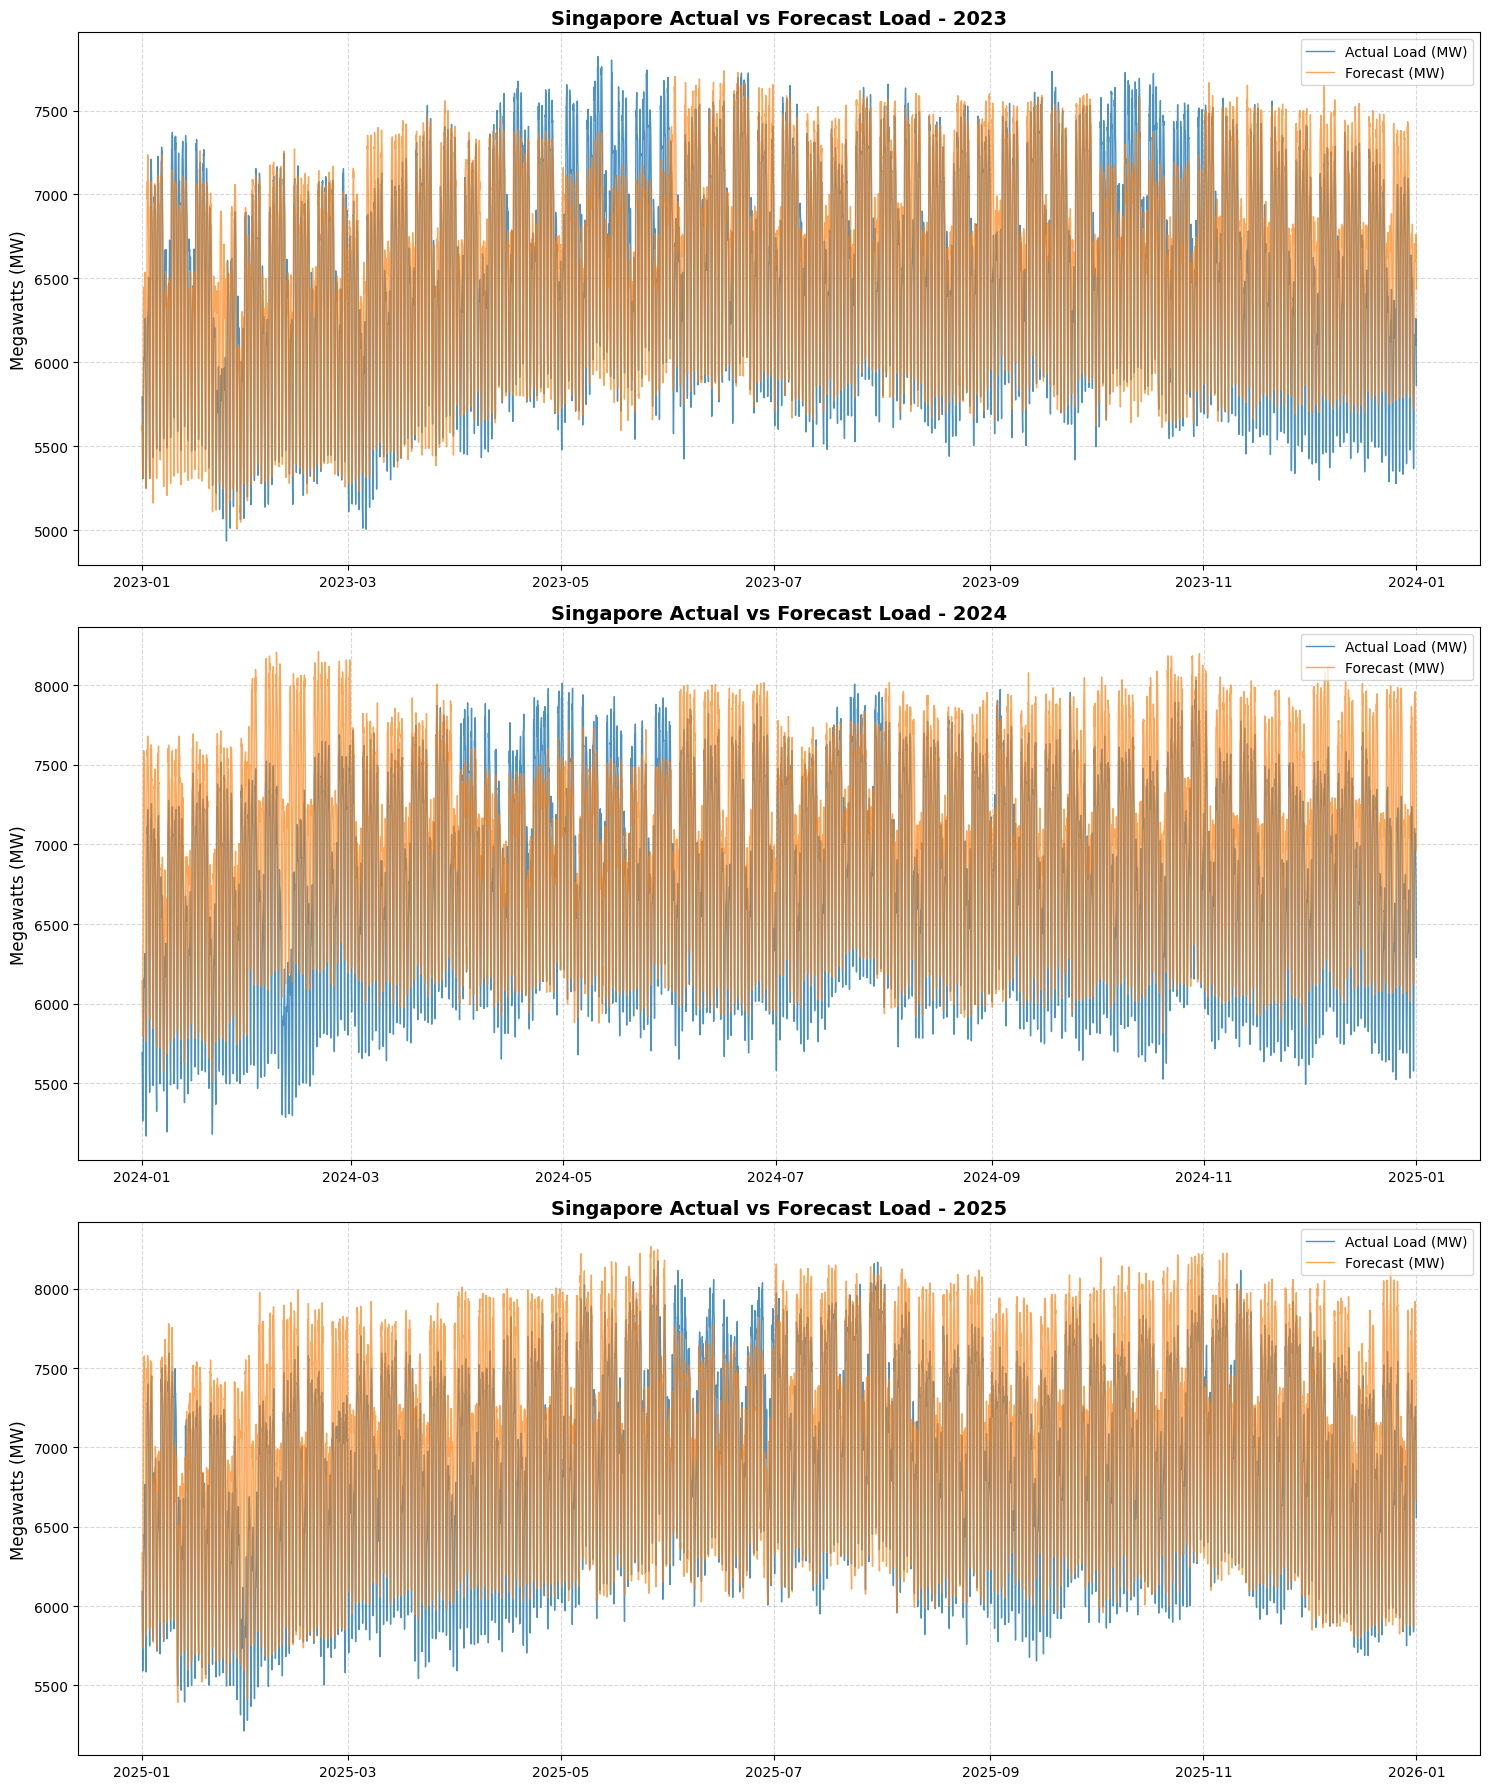

In [ ]:
#Create the comparison graph
import pandas as pd
import matplotlib.pyplot as plt
import datetime

df['Time (LOCAL)'] = pd.to_datetime(df['Time (LOCAL)'])

df['Year'] = df['Time (LOCAL)'].dt.year
years = sorted(df['Year'].unique())

fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(15, 6 * len(years)), sharex=False)

if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    # Filter data for the specific year
    yearly_data = df[df['Year'] == year]
    
    # Plot Actual Load (Blue)
    axes[i].plot(yearly_data['Time (LOCAL)'], yearly_data['Load (MW)'], 
                 label='Actual Load (MW)', color='#1f77b4', alpha=0.8, linewidth=1)
    
    # Plot Forecast Load (Red/Orange)
    axes[i].plot(yearly_data['Time (LOCAL)'], yearly_data['Forecast load (MW)'], 
                 label='Forecast (MW)', color='#ff7f0e', alpha=0.7, linewidth=1)
    
    # Formatting
    axes[i].set_title(f'Singapore Actual vs Forecast Load - {year}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Megawatts (MW)', fontsize=12)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.5)

date = str(datetime.datetime.now().date()).replace('-','')
time = datetime.datetime.now().time().strftime('%H:%M').replace(':','')
# Adjust layout to prevent overlapping text
plt.tight_layout()
# Save the high-resolution image to your folder
plt.savefig(f"Actual_vs_Forecast_{date}_{time}.png", dpi=300)
plt.show()

In [230]:
# Error metrics

y_true = df['Load (MW)']
y_pred = df['Forecast load (MW)']

# Calculations
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse) # Or root_mean_squared_error(y_true, y_pred) in newer versions
mape = mean_absolute_percentage_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# Displaying results
print(f"MSE:  {mse:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape * 100:.2f}%")
print(f"R2 Score: {r2:.4f}")

MSE:  92016.82 MW
RMSE: 303.34 MW
MAPE: 3.48%
R2 Score: 0.7819
